# Часть 1

- `recency` — количество месяцев с момента последней покупки. Этот атрибут помогает понять, как долго клиент не совершал покупок (индикатором его вовлечённости).
- `history_segment` — категоризация расходов клиента за последний год. Этот атрибут позволяет сегментировать клиентов по уровню их трат (помощь в таргетировании предложений).
- `history` — фактическая сумма (в $), потраченная клиентом за последний год. Этот атрибут предоставляет информацию о финансовом поведении клиента.
- `mens` — индикатор (1/0), где 1 означает, что клиент покупал товары для мужчин в течение последнего года. Это помогает определить предпочтения клиента.
- `womens` — индикатор (1/0), где 1 означает, что клиент покупал товары для женщин в течение последнего года. Это также помогает определить предпочтения клиента.
- `zip_code` — классификация почтового индекса (город, пригород, село). Этот атрибут может быть полезен для географического анализа клиентов.
- `newbie` — индикатор (1/0), где 1 обозначает нового клиента (в течение последних двенадцати месяцев). Это поможет оценить эффективность маркетинговых стратегий для привлечения новых клиентов.
- `channel` — описание каналов, через которые клиент совершал покупки в течение последнего года. Этот атрибут поможет с анализом предпочтений клиентов по каналам продаж (0 — мультиканал, 1 — мобильный, 2 — веб).
- `treatment` — индикатор (1/0), где 1 означает, что клиент получил промокод. Этот атрибут позволяет оценить влияние предложения на поведение клиента и его решение о покупке.
- `target` — индикатор (1/0), где 1 означает, что клиент успешно использовал промокод.

## Этап 1

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k
from sklift.viz import plot_qini_curve, plot_uplift_curve
from causalml.inference.meta import BaseTClassifier, BaseRClassifier

import optuna
from optuna import create_study
from optuna.visualization import plot_slice, plot_param_importances


plt.style.use('ggplot')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
data = pd.read_csv("uplift_fp_data.csv")

print(data.info())

data.drop_duplicates(ignore_index=True, inplace=True)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56985 entries, 0 to 56984
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          56985 non-null  int64  
 1   history_segment  56985 non-null 

In [3]:
data.head(5)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


## Этап 2

### EDA


In [4]:
group_treatment = data.groupby('treatment').agg('mean')
group_treatment

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target
treatment,,,,,,,,,
0,5.660445,1.666526,268.571940,0.558240,0.556231,0.750648,0.502089,1.297600,0.152673
1,5.651391,1.658594,267.219681,0.554256,0.556292,0.753588,0.503732,1.295318,0.160186


<Axes: xlabel='treatment', ylabel='target'>

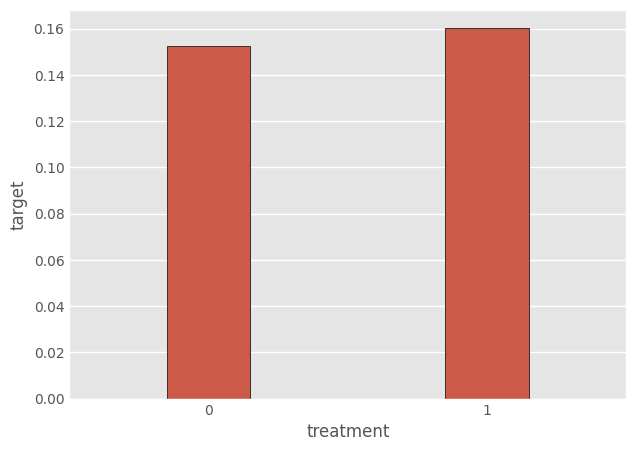

In [5]:
sns.barplot(
    data=group_treatment,
    x='treatment',
    y='target',
    width=0.3,
    edgecolor='black'
    )

Сделайте вывод на основе EDA в данной ячейке

# Этап 2

### Проверка на статистическую значимость

Обоснуйте выбор статистического теста в данной ячейке

Т.к. traget имеет распределение Бернулли (бинарные значения), для оценки статистической значимости подходит z-тест.

In [34]:
data_ctrl = data.loc[data['treatment'] == 0, 'target']
data_test = data.loc[data['treatment'] == 1, 'target']


pCtrl, nCtrl = data_ctrl.sum() / len(data_ctrl), len(data_ctrl)
pTest, nTest = data_test.sum() / len(data_test), len(data_test)

print("P contr:", pCtrl, "N contr:", nCtrl)
print("P test:", pTest, "N test:", nTest)

mu = pTest - pCtrl
sigma = np.sqrt(pTest * (1 - pTest) / nTest + pCtrl * (pCtrl) / nCtrl)

p_value = 1 - stats.norm.cdf(mu / sigma)
print(f"P-value={p_value} < alpha=0.05: различия стат. значимы")

P contr: 0.15267276476497646 N contr: 37826
P test: 0.16018581345581712 N test: 19159
P-value=0.003278743836095832 < alpha=0.05: различия стат. значимы


## Построение корреляций

<Axes: >

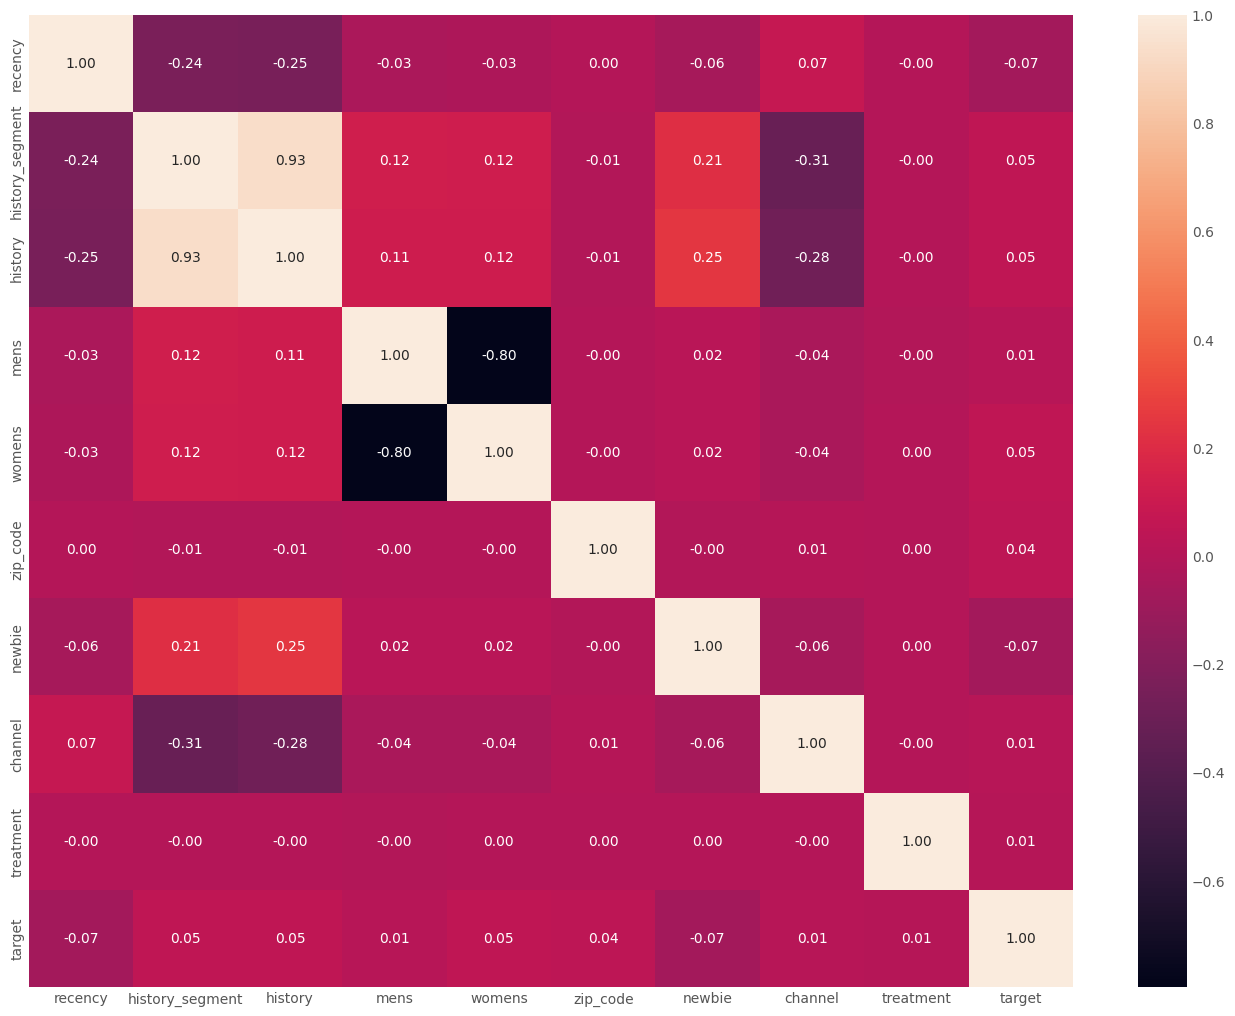

In [35]:
corr_m = data.corr(method='pearson')


plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_m,
    annot=True,
    fmt=".2f"
    )

Сделайте вывод о корреляциях признаков друг с другом и таргетом в этой ячейке

- Линейная связь с таргетом слабая для всех признаков
- Сильная связь по модлю наблюдается между признаками:
    - history - history_segment: объясняется тем, что history_segment - прозводный признак от history
    - mens - womens: женщины покупают чаще товары для женщин, мужчины - для мужчин
- Разделение на группы корректно, т.к. не наблюдается связи признаков с разделением на группы (treatment)

## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [53]:
X = data.drop(['target'], axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                    stratify=data[['target', 'treatment']],
                                    random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((45588, 9), (11397, 9), (45588,), (11397,))

### Обучение выбранного бейзлайна

In [37]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)
model.fit(X_train, y_train)

X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated['treatment'] = 1
X_test_control['treatment'] = 0

y_pred_treated = model.predict_proba(X_test_treated)[:,1]
y_pred_control = model.predict_proba(X_test_control)[:,1]

uplift = y_pred_treated - y_pred_control

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


### Расчет метрик для выбранного бейзлайна на тестовой выборке

Qini AUC = 0.064
Uplift AUC = 0.031
Uplift@30% = 0.054


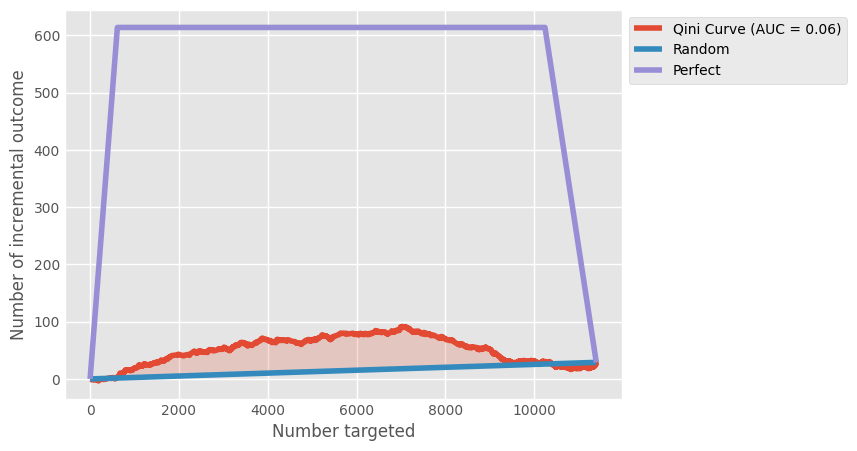

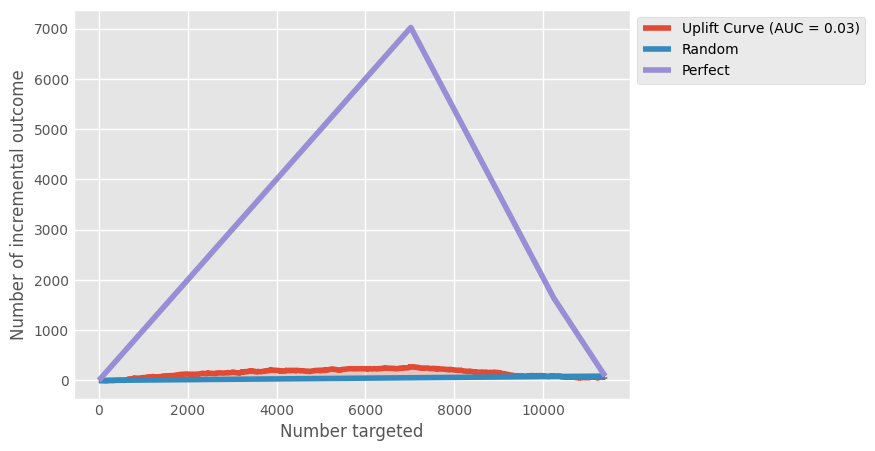

In [38]:
plot_qini_curve(y_test, uplift, X_test['treatment'], perfect=True,
                  name='Qini Curve')
qini_score = qini_auc_score(y_test.values, uplift, X_test['treatment'].values)
print(f'Qini AUC = {qini_score:.3f}')

plot_uplift_curve(y_test, uplift, X_test['treatment'], perfect=True,
                  name='Uplift Curve')

uplift_score = uplift_auc_score(y_test.values, uplift, X_test['treatment'].values)
print(f'Uplift AUC = {uplift_score:.3f}')

uplift_30 = uplift_at_k(y_test.values, uplift, X_test['treatment'].values, k=0.3, strategy='overall')
print(f'Uplift@30% = {uplift_30:.3f}')


<Axes: xlabel='importance', ylabel='None'>

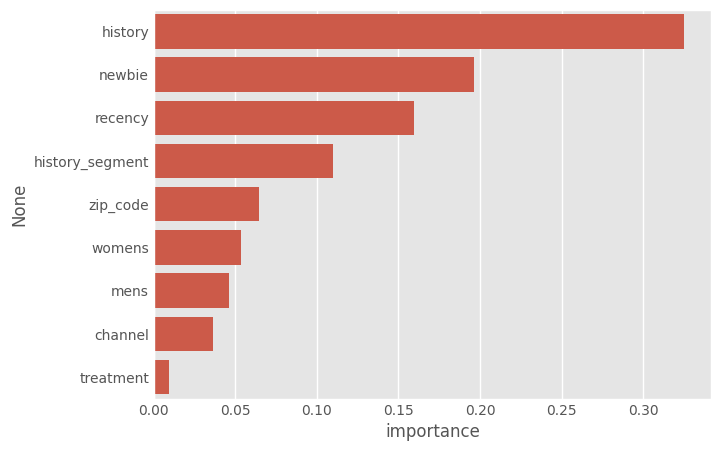

In [39]:
fi = dict(zip(model.feature_names_in_, model.feature_importances_))
fi_rf = pd.Series(fi).sort_values(ascending=False).to_frame(name='importance')
sns.barplot(data=fi_rf, x='importance', y=fi_rf.index)

# Обучение 2 моделей 

### Обучение модели 1

In [40]:
treatment_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)

control_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)

t_learner = BaseTClassifier(
    treatment_learner=treatment_model,
    control_learner=control_model,
    control_name=0,
)

X_train_features = X_train.drop('treatment', axis=1)
X_test_features = X_test.drop('treatment', axis=1)

t_learner.fit(
    X=X_train_features.values,  # Признаки без treatment
    treatment=X_train['treatment'].values,      # Столбец с признаком воздействия
    y=y_train.values                            # Целевая переменная
)

uplift_pred = t_learner.predict(X_test_features.values)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


### Получение метрик по модели 1

Qini AUC = 0.058
Uplift AUC = 0.027
Uplift@30% = 0.042


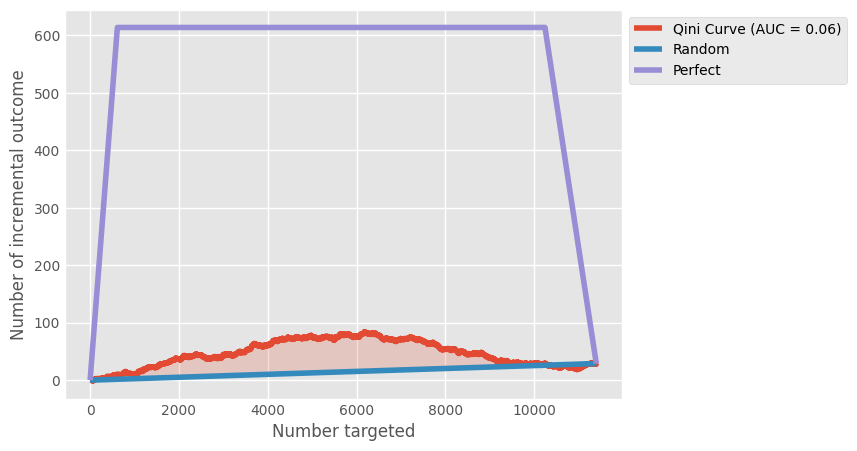

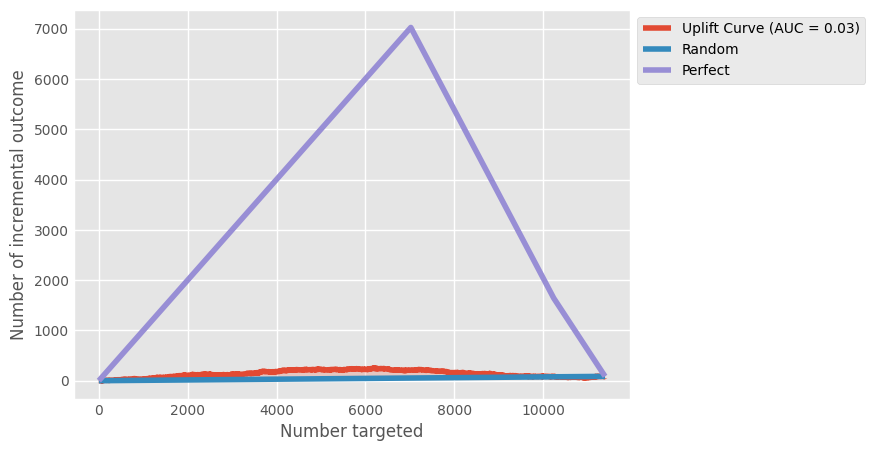

In [41]:
plot_qini_curve(y_test.values, uplift_pred.squeeze(), X_test['treatment'], perfect=True,
                  name='Qini Curve')
qini_score = qini_auc_score(y_test.values, uplift_pred.squeeze(), X_test['treatment'].values)
print(f'Qini AUC = {qini_score:.3f}')

plot_uplift_curve(y_test.values, uplift_pred.squeeze(), X_test['treatment'], perfect=True,
                  name='Uplift Curve')

uplift_score = uplift_auc_score(y_test.values, uplift_pred.squeeze(), X_test['treatment'].values)
print(f'Uplift AUC = {uplift_score:.3f}')

uplift_30 = uplift_at_k(y_test.values, uplift_pred.squeeze(), X_test['treatment'].values, k=0.3, strategy='overall')
print(f'Uplift@30% = {uplift_30:.3f}')

### Обучение модели 2

In [42]:
features = data.drop(columns=['target','treatment']).columns
T = X_train.treatment.values  # 1 - treatment, 0 - control
X_train = X_train[features]
y_train = y_train.values  # целевая переменная
T_test = X_test.treatment.values

outcome_learner = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)

effect_learner = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1
)

propensity_learner = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)

r_learner = BaseRClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    propensity_learner=propensity_learner
    )

e_x = np.zeros(len(X_train))
T_test = X_test.treatment.values

model_e = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)
model_e.fit(X_train, T)
e_x = model_e.predict_proba(X_train)[:, 1]

r_learner.fit(
    X=X_train,
    treatment=T,
    y=y_train,
    p=e_x,
    verbose=True
)

uplift_pred = r_learner.predict(X_test.drop(columns=['treatment']).values)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 

### Получение метрик по модели 2

Qini AUC: 0.056
Uplift AUC: 0.027
Uplift@30% = 0.045


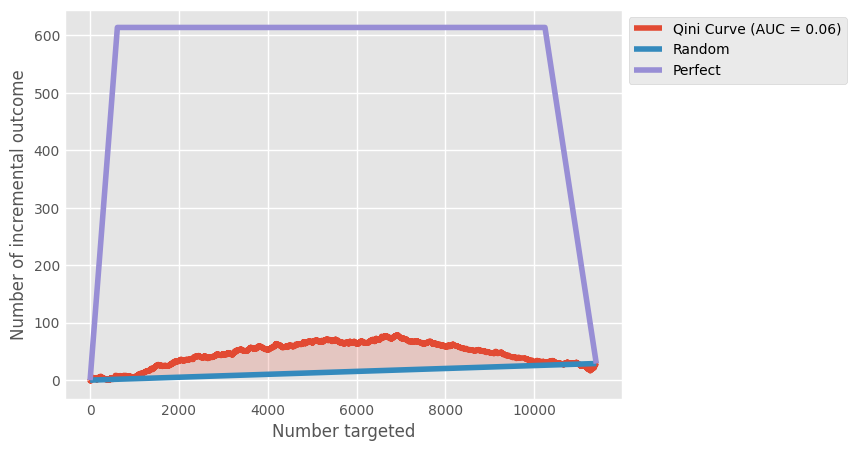

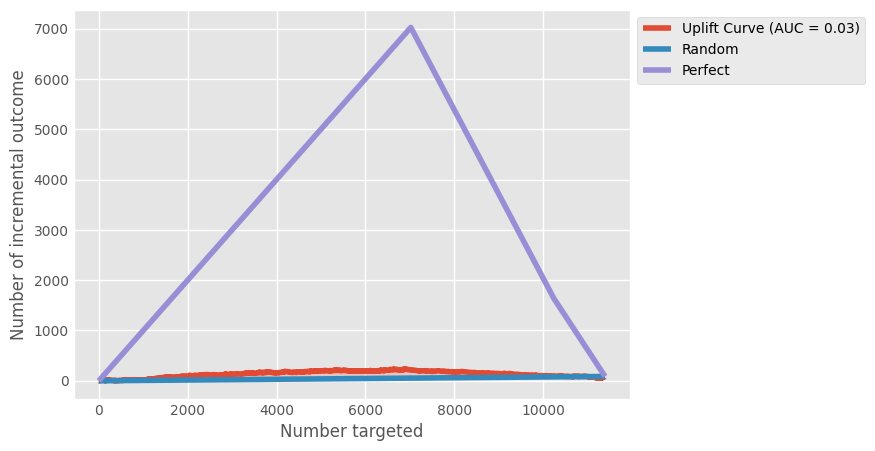

In [48]:
plot_qini_curve(y_test.values, uplift_pred.squeeze(), X_test['treatment'], perfect=True,
                  name='Qini Curve')

plot_uplift_curve(y_test.values, uplift_pred.squeeze(), X_test['treatment'], perfect=True,
                  name='Uplift Curve')

qini_auc = qini_auc_score(y_test, uplift_pred.squeeze(), T_test)
uplift_auc = uplift_auc_score(y_test, uplift_pred.squeeze(), T_test)

print(f"Qini AUC: {qini_auc:.3f}")
print(f"Uplift AUC: {uplift_auc:.3f}")

uplift_30 = uplift_at_k(y_test.values, uplift_pred.squeeze(), X_test['treatment'].values, k=0.3, strategy='overall')
print(f'Uplift@30% = {uplift_30:.3f}')

### Метрики
___
**S-learner**:
- Qini AUC = 0.064
- Uplift AUC = 0.031
- Uplift@30% = `0.054`

**T-learner**:
- Qini AUC = 0.058
- Uplift AUC = 0.027
- Uplift@30% = `0.042`

**R-learner**:
- Qini AUC: 0.056
- Uplift AUC: 0.027
- Uplift@30% = `0.045`

Qini AUC, Uplift AUC, Uplift@30% у **S-learner** наивысший.

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [24]:
from optuna import create_study
from sklift.metrics import uplift_at_k

X = data.drop(['target'], axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                    stratify=data[['target', 'treatment']],
                                    random_state=42)

strat = pd.concat([y_train, X_train[['treatment']]], axis=1)
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                    stratify=strat,
                                    random_state=42)

X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated['treatment'] = 1
X_test_control['treatment'] = 0

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 120),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'criterion': trial.suggest_categorical('criterion', ['entropy', 'gini']),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
        }
    model = RandomForestClassifier(**params)
    model.fit(X_train_val, y_train_val)

    X_val_treated = X_val.copy()
    X_val_control = X_val.copy()

    X_val_treated['treatment'] = 1
    X_val_control['treatment'] = 0

    y_pred_treated = model.predict_proba(X_val_treated)[:,1]
    y_pred_control = model.predict_proba(X_val_control)[:,1]
    uplift_pred = y_pred_treated - y_pred_control

    uplift_at_30 = uplift_at_k(y_val, uplift_pred, X_val['treatment'], k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=50, multivariate=True)
study = create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=1000, show_progress_bar=True)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)

plot_slice(study).show()
plot_param_importances(study).show()

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.



  0%|          | 0/1000 [00:00<?, ?it/s]

Best hyperparameters:  {'n_estimators': 119, 'max_depth': 5, 'criterion': 'gini', 'max_features': 'log2'}
Best score:  0.042888369864654455


## Этап 2

### Визуализация результатов

Qini AUC = 0.055
Uplift AUC = 0.026
Uplift@30% = 0.043


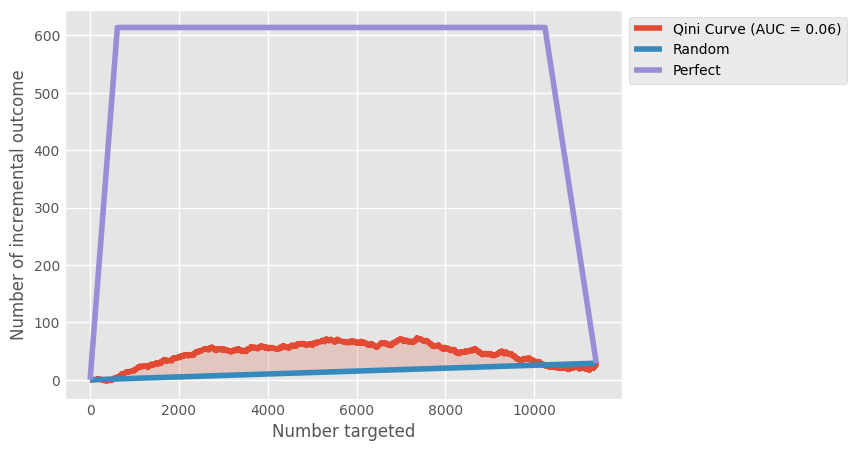

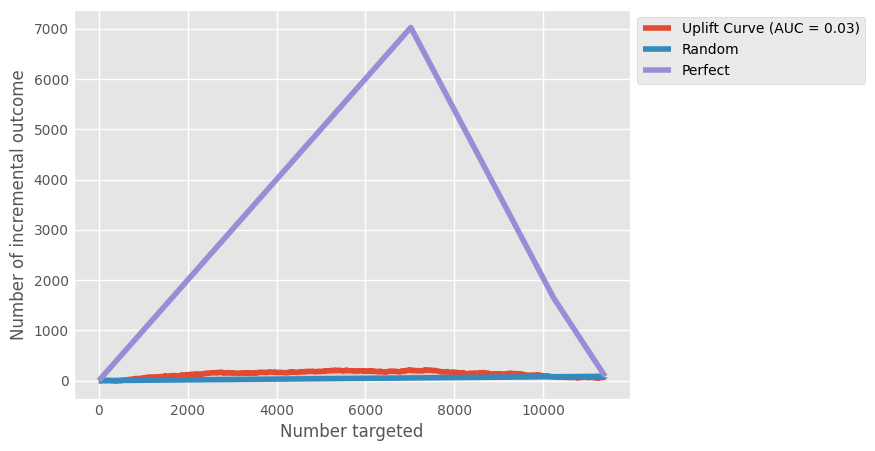

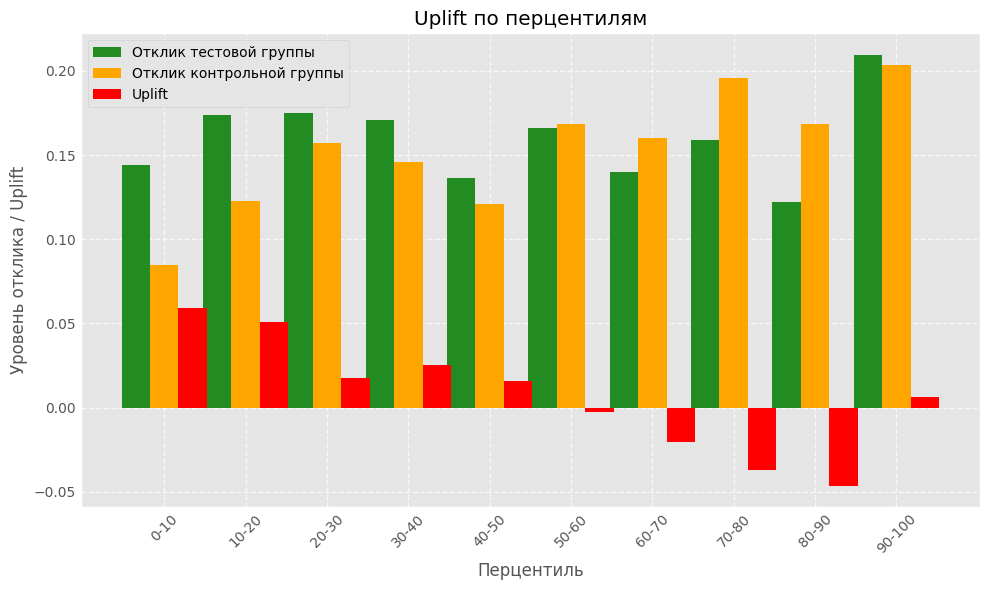

In [25]:
from utils import custom_uplift_by_percentile

best_params = study.best_params
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_treated = best_model.predict_proba(X_test_treated)[:,1]
y_pred_control = best_model.predict_proba(X_test_control)[:,1]
uplift_pred = y_pred_treated - y_pred_control

plot_qini_curve(y_test, uplift_pred, X_test['treatment'], perfect=True,
                  name='Qini Curve')
qini_score = qini_auc_score(y_test.values, uplift_pred, X_test['treatment'].values)
print(f'Qini AUC = {qini_score:.3f}')

plot_uplift_curve(y_test, uplift_pred, X_test['treatment'], perfect=True,
                  name='Uplift Curve')

uplift_score = uplift_auc_score(y_test.values, uplift_pred, X_test['treatment'].values)
print(f'Uplift AUC = {uplift_score:.3f}')

uplift_30 = uplift_at_k(y_test.values, uplift_pred, X_test['treatment'].values, k=0.3, strategy='overall')
print(f'Uplift@30% = {uplift_30:.3f}')

fig = custom_uplift_by_percentile(
    y_test,
    uplift_pred,
    X_test['treatment'],
    kind='bar',
    bins=10,
    title='Uplift по перцентилям'
)

- Модель правильно предсказывает, т.к. положительный uplift сконцентрирован в превых перцентилях
- Положительный uplift для 30% пользователей 

# Этап 3

In [28]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """

    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.

        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = feature_names
        self.logger = logger

        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.

        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки


        return X

    def predict(self, X):
        """
        Получение предсказаний uplift.

        Аргументы:
            X: pandas.DataFrame с признаками

        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None

        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)

        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)

        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        X_t = X.copy()
        X_c = X.copy()

        X_t['treatment'] = 1
        X_c['treatment'] = 0

        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")

        y_pred_t = best_model.predict_proba(X_t)[:,1]
        y_pred_c = best_model.predict_proba(X_c)[:,1]
        uplift = y_pred_t - y_pred_c

        if self.logger:
            self.logger.info("Предсказания успешно завершены")

        return uplift


In [39]:
import logging

logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger()

model = UpliftModelInference(model=best_model,
                             feature_names= ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel'],
                             logger=logger
                             )

INFO:root:Модель UpliftModel инициализирована с признаками: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']


In [33]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3],
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [40]:
# проверка работы класса
model.predict(test_data)

INFO:root:Выполняем предсказания для данных размерности (3, 8)
DEBUG:root:Начинаем преобразование данных
DEBUG:root:Преобразование входных данных размерности (3, 8)
DEBUG:root:Выполняем предсказания модели
INFO:root:Предсказания успешно завершены


array([ 0.00202784,  0.00179768, -0.00150363])